# Análisis del Impacto del Uso de Redes Sociales en Estudiantes

## Arquitectura Analítica Basada en Agente Orquestador y Skills Modulares

Este notebook implementa un sistema analítico completo para analizar el impacto del uso de redes sociales sobre:
- Salud mental
- Hábitos de sueño
- Rendimiento académico
- Comportamiento digital estudiantil

### Arquitectura del Sistema

El sistema sigue una arquitectura basada en:
- **Agente Orquestador**: Coordina la ejecución de skills analíticos especializados
- **Skills Modulares**: Cada skill implementa una fase específica del análisis
- **Análisis Dinámico**: Generación automática de insights y alertas
- **Evaluación Comparativa**: Selección automática del mejor modelo

### Skills Integradas

1. **Data Wrangling**: Limpieza y preparación del dataset
2. **EDA**: Análisis exploratorio de datos
3. **Correlation Analysis**: Análisis de correlaciones y relaciones
4. **Model Selection**: Evaluación y selección de modelos analíticos
5. **Insight Generation**: Generación de insights y recomendaciones

## Objetivos del Proyecto

- Analizar patrones de uso de redes sociales en estudiantes
- Identificar relaciones entre uso digital, sueño y salud mental
- Detectar grupos de riesgo y patrones de comportamiento
- Evaluar modelos analíticos para predicción y clasificación
- Generar insights accionables y recomendaciones basadas en evidencia

## Importación de Librerías

In [57]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from scipy import stats

# Librerías de machine learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    silhouette_score
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Ignorar warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


## Carga del Dataset

In [58]:
# Definir ruta del dataset
data_path = Path('Data set.csv')

# Cargar dataset
df = pd.read_csv(data_path, sep=';')

# Mostrar información básica
print("=" * 60)
print("INFORMACIÓN DEL DATASET")
print("=" * 60)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "=" * 60)
print("PRIMERAS FILAS")
print("=" * 60)
display(df.head())

INFORMACIÓN DEL DATASET
Dimensiones: 1705 filas × 11 columnas
Memoria: 0.61 MB

PRIMERAS FILAS


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [59]:
# Información del dataset
print("=" * 60)
print("INFORMACIÓN DE COLUMNAS")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
display(df.describe())

INFORMACIÓN DE COLUMNAS
<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   str    
 3   Academic_Level                1705 non-null   str    
 4   Country                       1705 non-null   str    
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   str    
 7   Affects_Academic_Performance  1705 non-null   str    
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 146.7 KB

ESTADÍSTICAS DESCRIPTIVAS


,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


---

# 1. DATA WRANGLING

## Objetivo

Limpiar, validar y preparar el dataset antes de ejecutar análisis estadísticos o generación de insights.

### Responsabilidades
- Detección de valores nulos
- Tratamiento de datos faltantes
- Eliminación de duplicados
- Detección de outliers mediante IQR
- Validación de tipos de datos

### 1.1 Detección de Valores Nulos

In [60]:
# Detección de valores nulos
print("=" * 60)
print("DETECCIÓN DE VALORES NULOS")
print("=" * 60)

null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

null_summary = pd.DataFrame({
    'Nulos': null_counts,
    'Porcentaje': null_percentages
})

print(null_summary)

# Estrategia automática de tratamiento
print("\n" + "=" * 60)
print("ESTRATEGIA DE TRATAMIENTO")
print("=" * 60)

for col in df.columns:
    null_pct = null_percentages[col]
    if null_pct == 0:
        continue
    elif null_pct < 5:
        print(f"{col}: {null_pct:.2f}% nulos → Eliminar filas")
    elif 5 <= null_pct <= 20:
        if df[col].dtype in ['int64', 'float64']:
            print(f"{col}: {null_pct:.2f}% nulos → Imputar mediana (numérico)")
        else:
            print(f"{col}: {null_pct:.2f}% nulos → Imputar moda (categórico)")
    else:
        print(f"{col}: {null_pct:.2f}% nulos → ALERTA: Posible exclusión")

DETECCIÓN DE VALORES NULOS
                              Nulos  Porcentaje
Student_ID                        0         0.0
Age                               0         0.0
Gender                            0         0.0
Academic_Level                    0         0.0
Country                           0         0.0
Avg_Daily_Usage_Hours             0         0.0
Most_Used_Platform                0         0.0
Affects_Academic_Performance      0         0.0
Sleep_Hours_Per_Night             0         0.0
Mental_Health_Score               0         0.0
Overall_Impact                    0         0.0

ESTRATEGIA DE TRATAMIENTO


In [61]:
# Aplicar estrategia de tratamiento
df_clean = df.copy()
rows_before = len(df_clean)

for col in df_clean.columns:
    null_pct = (df_clean[col].isnull().sum() / len(df_clean)) * 100
    
    if null_pct == 0:
        continue
    elif null_pct < 5:
        df_clean = df_clean.dropna(subset=[col])
    elif 5 <= null_pct <= 20:
        if df_clean[col].dtype in ['int64', 'float64']:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
        else:
            mode_val = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_val, inplace=True)

rows_after = len(df_clean)
print(f"Filas eliminadas: {rows_before - rows_after}")
print(f"Filas restantes: {rows_after}")

Filas eliminadas: 0
Filas restantes: 1705


### 1.2 Detección y Eliminación de Duplicados

In [62]:
# Detección de duplicados
print("=" * 60)
print("DETECCIÓN DE DUPLICADOS")
print("=" * 60)

duplicates = df_clean.duplicated().sum()
print(f"Registros duplicados: {duplicates}")

if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Registros duplicados eliminados: {duplicates}")
    print(f"Filas restantes: {len(df_clean)}")
else:
    print("No se encontraron duplicados")

DETECCIÓN DE DUPLICADOS
Registros duplicados: 0
No se encontraron duplicados


### 1.3 Detección de Outliers (Método IQR)

In [63]:
# Variables numéricas para análisis de outliers
numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']

print("=" * 60)
print("DETECCIÓN DE OUTLIERS (MÉTODO IQR)")
print("=" * 60)

outlier_summary = {}

for col in numeric_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df_clean)) * 100
        
        outlier_summary[col] = {
            'count': outlier_count,
            'percentage': outlier_pct,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
        
        print(f"\n{col}:")
        print(f"  Q1: {Q1:.2f}")
        print(f"  Q3: {Q3:.2f}")
        print(f"  IQR: {IQR:.2f}")
        print(f"  Límite inferior: {lower_bound:.2f}")
        print(f"  Límite superior: {upper_bound:.2f}")
        print(f"  Outliers detectados: {outlier_count} ({outlier_pct:.2f}%)")

DETECCIÓN DE OUTLIERS (MÉTODO IQR)

Age:
  Q1: 19.00
  Q3: 22.00
  IQR: 3.00
  Límite inferior: 14.50
  Límite superior: 26.50
  Outliers detectados: 0 (0.00%)

Avg_Daily_Usage_Hours:
  Q1: 3.80
  Q3: 6.30
  IQR: 2.50
  Límite inferior: 0.05
  Límite superior: 10.05
  Outliers detectados: 0 (0.00%)

Sleep_Hours_Per_Night:
  Q1: 5.60
  Q3: 7.50
  IQR: 1.90
  Límite inferior: 2.75
  Límite superior: 10.35
  Outliers detectados: 0 (0.00%)

Mental_Health_Score:
  Q1: 5.00
  Q3: 7.00
  IQR: 2.00
  Límite inferior: 2.00
  Límite superior: 10.00
  Outliers detectados: 0 (0.00%)


In [64]:
# Explicación sobre outliers
print("=" * 60)
print("INTERPRETACIÓN DE OUTLIERS")
print("=" * 60)
print("\nLos outliers detectados NO se eliminarán automáticamente.")
print("\nCriterio de decisión:")
print("- Si parecen comportamiento real → CONSERVAR para análisis")
print("- Si parecen errores → POSIBLE corrección manual")
print("\nEn este contexto de análisis de comportamiento estudiantil,")
print("los outliers pueden representar casos extremos válidos")
print("(ej. estudiantes con uso muy elevado de redes sociales).")

INTERPRETACIÓN DE OUTLIERS

Los outliers detectados NO se eliminarán automáticamente.

Criterio de decisión:
- Si parecen comportamiento real → CONSERVAR para análisis
- Si parecen errores → POSIBLE corrección manual

En este contexto de análisis de comportamiento estudiantil,
los outliers pueden representar casos extremos válidos
(ej. estudiantes con uso muy elevado de redes sociales).


### 1.4 Validación de Tipos de Datos

In [65]:
# Validación de tipos de datos
print("=" * 60)
print("VALIDACIÓN DE TIPOS DE DATOS")
print("=" * 60)

print("\nVariables numéricas:")
numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols_clean:
    print(f"  - {col}: {df_clean[col].dtype}")

print("\nVariables categóricas:")
categorical_cols_clean = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols_clean:
    print(f"  - {col}: {df_clean[col].dtype}")

print("\n" + "=" * 60)
print("RESUMEN DATA WRANGLING")
print("=" * 60)
print(f"Dataset original: {len(df)} filas")
print(f"Dataset limpio: {len(df_clean)} filas")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")
print(f"Porcentaje de datos conservados: {(len(df_clean)/len(df))*100:.2f}%")

VALIDACIÓN DE TIPOS DE DATOS

Variables numéricas:
  - Student_ID: int64
  - Age: int64
  - Avg_Daily_Usage_Hours: float64
  - Sleep_Hours_Per_Night: float64
  - Mental_Health_Score: float64

Variables categóricas:
  - Gender: str
  - Academic_Level: str
  - Country: str
  - Most_Used_Platform: str
  - Affects_Academic_Performance: str
  - Overall_Impact: str

RESUMEN DATA WRANGLING
Dataset original: 1705 filas
Dataset limpio: 1705 filas
Filas eliminadas: 0
Porcentaje de datos conservados: 100.00%


---

# 2. EXPLORATORY DATA ANALYSIS (EDA)

## Objetivo

Explorar distribuciones, patrones y relaciones iniciales dentro del dataset para comprender el comportamiento del uso de redes sociales y su posible impacto sobre el bienestar estudiantil.

### 2.1 Histogramas de Variables Numéricas

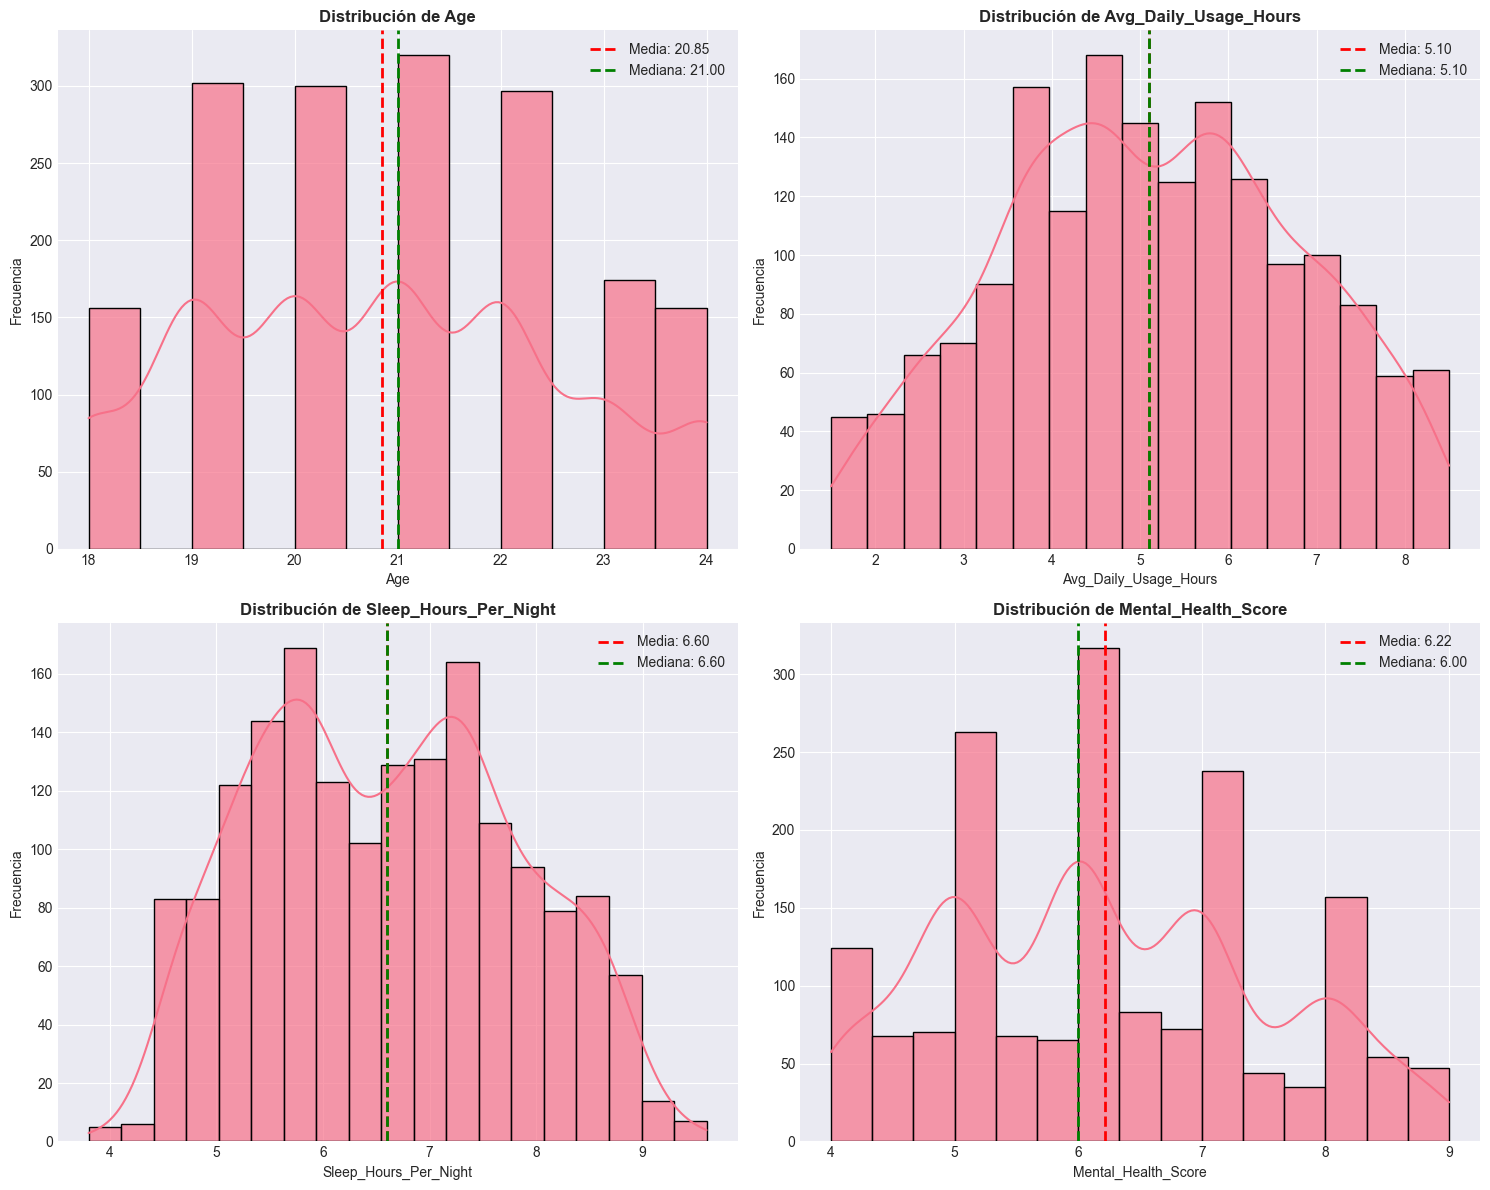

In [66]:
# Variables para análisis
eda_vars = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, var in enumerate(eda_vars):
    if var in df_clean.columns:
        ax = axes[idx]
        
        # Histograma con KDE
        sns.histplot(data=df_clean, x=var, kde=True, ax=ax, alpha=0.7)
        
        # Líneas de media y mediana
        mean_val = df_clean[var].mean()
        median_val = df_clean[var].median()
        
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        
        ax.set_title(f'Distribución de {var}', fontsize=12, fontweight='bold')
        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel('Frecuencia', fontsize=10)
        ax.legend()

plt.tight_layout()
plt.show()

In [67]:
# Interpretación de distribuciones
print("=" * 60)
print("INTERPRETACIÓN DE DISTRIBUCIONES")
print("=" * 60)

for var in eda_vars:
    if var in df_clean.columns:
        mean_val = df_clean[var].mean()
        median_val = df_clean[var].median()
        std_val = df_clean[var].std()
        skewness = df_clean[var].skew()
        
        print(f"\n{var}:")
        print(f"  Media: {mean_val:.2f}")
        print(f"  Mediana: {median_val:.2f}")
        print(f"  Desviación estándar: {std_val:.2f}")
        print(f"  Asimetría (skewness): {skewness:.2f}")
        
        if skewness > 0.5:
            print(f"  → Distribución con asimetría positiva (cola a la derecha)")
        elif skewness < -0.5:
            print(f"  → Distribución con asimetría negativa (cola a la izquierda)")
        else:
            print(f"  → Distribución aproximadamente simétrica")

INTERPRETACIÓN DE DISTRIBUCIONES

Age:
  Media: 20.85
  Mediana: 21.00
  Desviación estándar: 1.76
  Asimetría (skewness): 0.15
  → Distribución aproximadamente simétrica

Avg_Daily_Usage_Hours:
  Media: 5.10
  Mediana: 5.10
  Desviación estándar: 1.68
  Asimetría (skewness): -0.02
  → Distribución aproximadamente simétrica

Sleep_Hours_Per_Night:
  Media: 6.60
  Mediana: 6.60
  Desviación estándar: 1.21
  Asimetría (skewness): 0.13
  → Distribución aproximadamente simétrica

Mental_Health_Score:
  Media: 6.22
  Mediana: 6.00
  Desviación estándar: 1.28
  Asimetría (skewness): 0.21
  → Distribución aproximadamente simétrica


### 2.2 Boxplots para Detección de Outliers

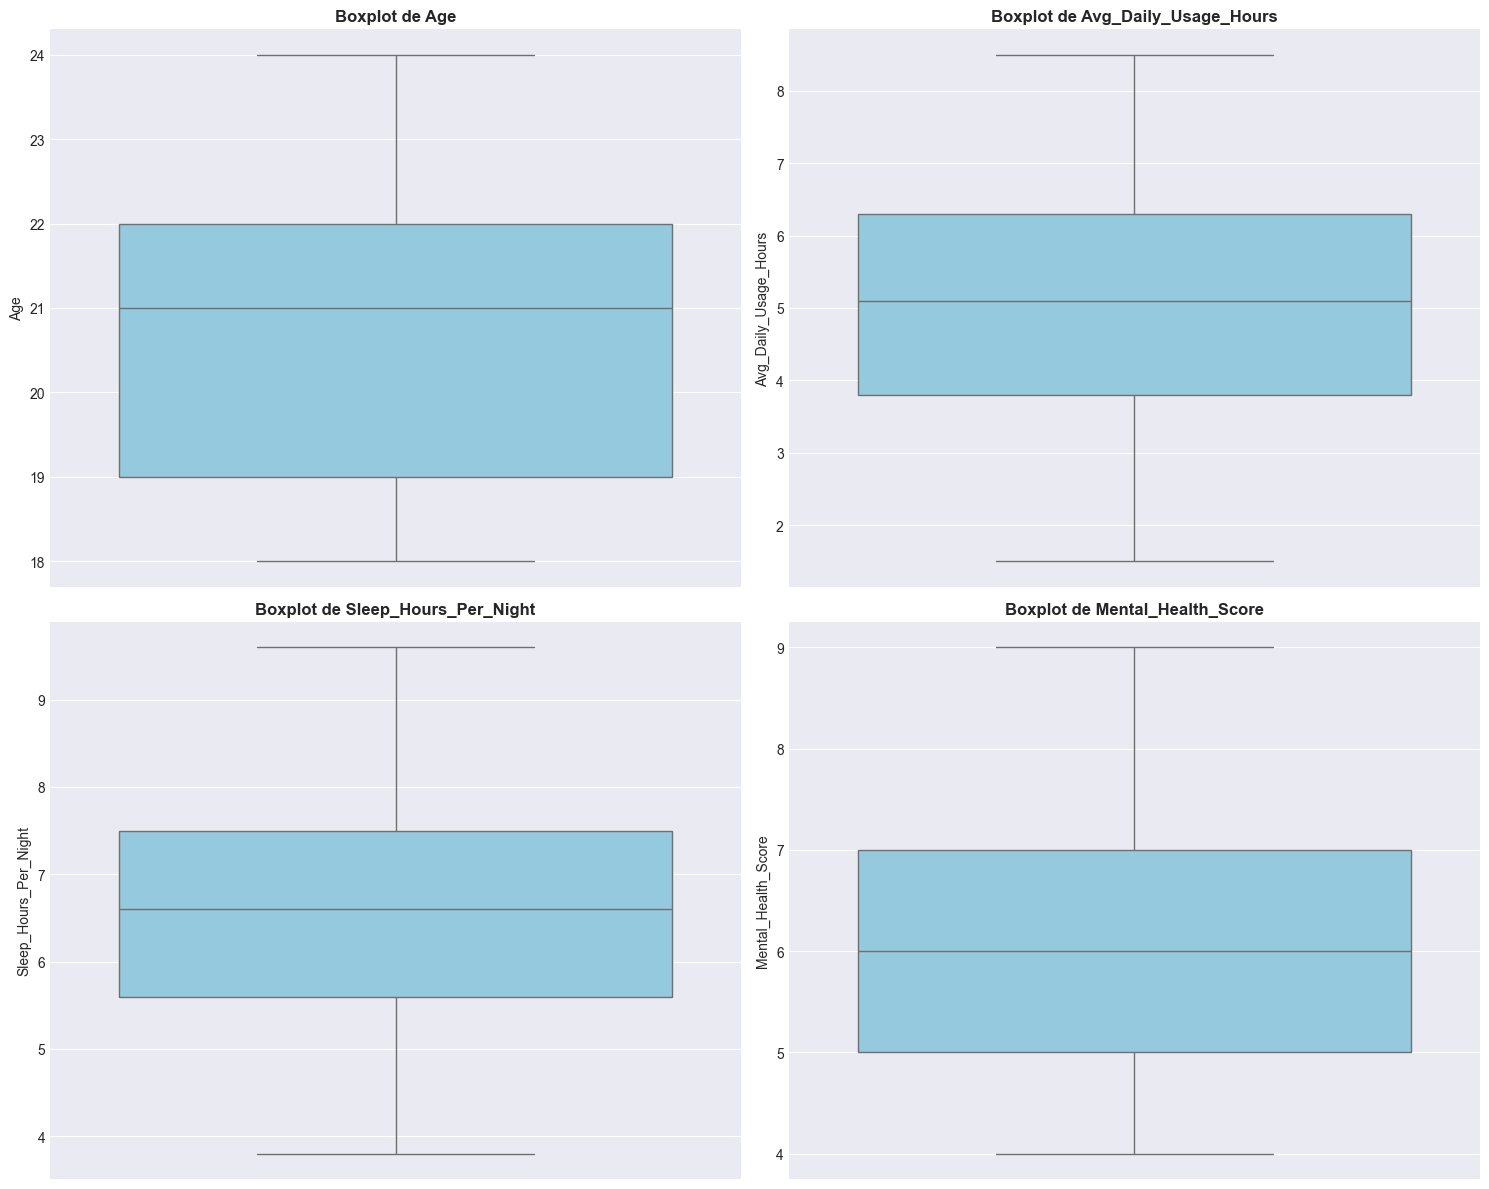

In [68]:
# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, var in enumerate(eda_vars):
    if var in df_clean.columns:
        ax = axes[idx]
        sns.boxplot(data=df_clean, y=var, ax=ax, color='skyblue')
        ax.set_title(f'Boxplot de {var}', fontsize=12, fontweight='bold')
        ax.set_ylabel(var, fontsize=10)

plt.tight_layout()
plt.show()

### 2.3 Comparaciones Categóricas

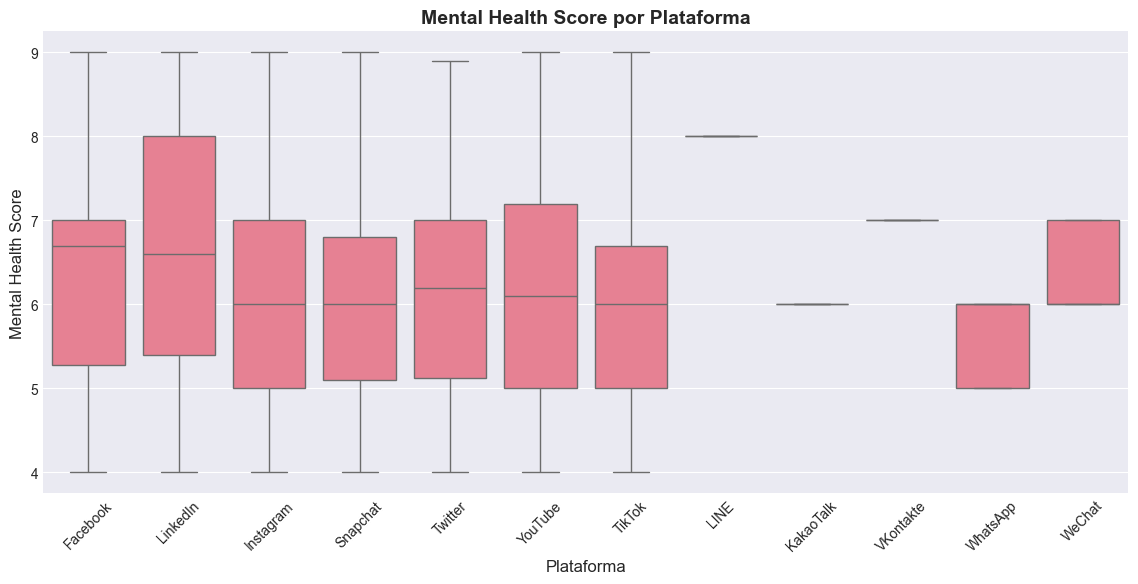

In [69]:
# Mental Health Score vs Most Used Platform
if 'Most_Used_Platform' in df_clean.columns and 'Mental_Health_Score' in df_clean.columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_clean, x='Most_Used_Platform', y='Mental_Health_Score')
    plt.title('Mental Health Score por Plataforma', fontsize=14, fontweight='bold')
    plt.xlabel('Plataforma', fontsize=12)
    plt.ylabel('Mental Health Score', fontsize=12)
    plt.xticks(rotation=45)
    plt.show()

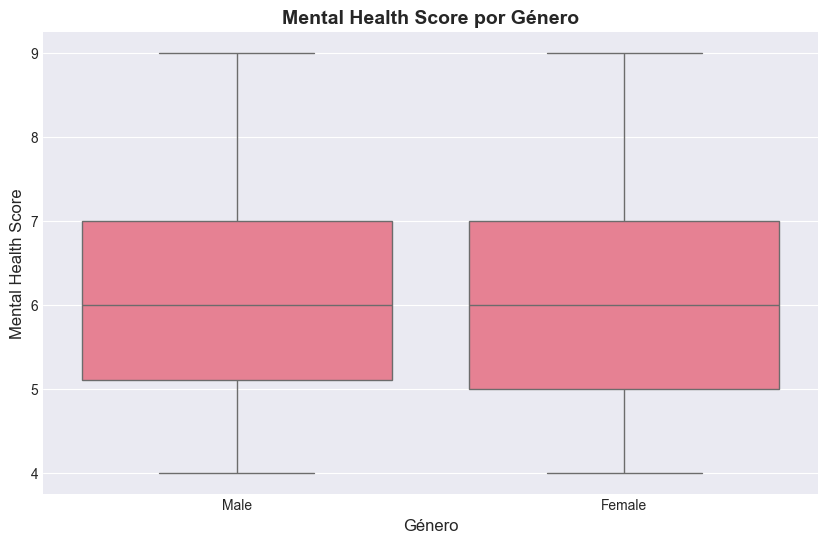

In [70]:
# Mental Health Score vs Gender
if 'Gender' in df_clean.columns and 'Mental_Health_Score' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x='Gender', y='Mental_Health_Score')
    plt.title('Mental Health Score por Género', fontsize=14, fontweight='bold')
    plt.xlabel('Género', fontsize=12)
    plt.ylabel('Mental Health Score', fontsize=12)
    plt.show()

### 2.4 Relaciones Bivariadas con Línea de Tendencia

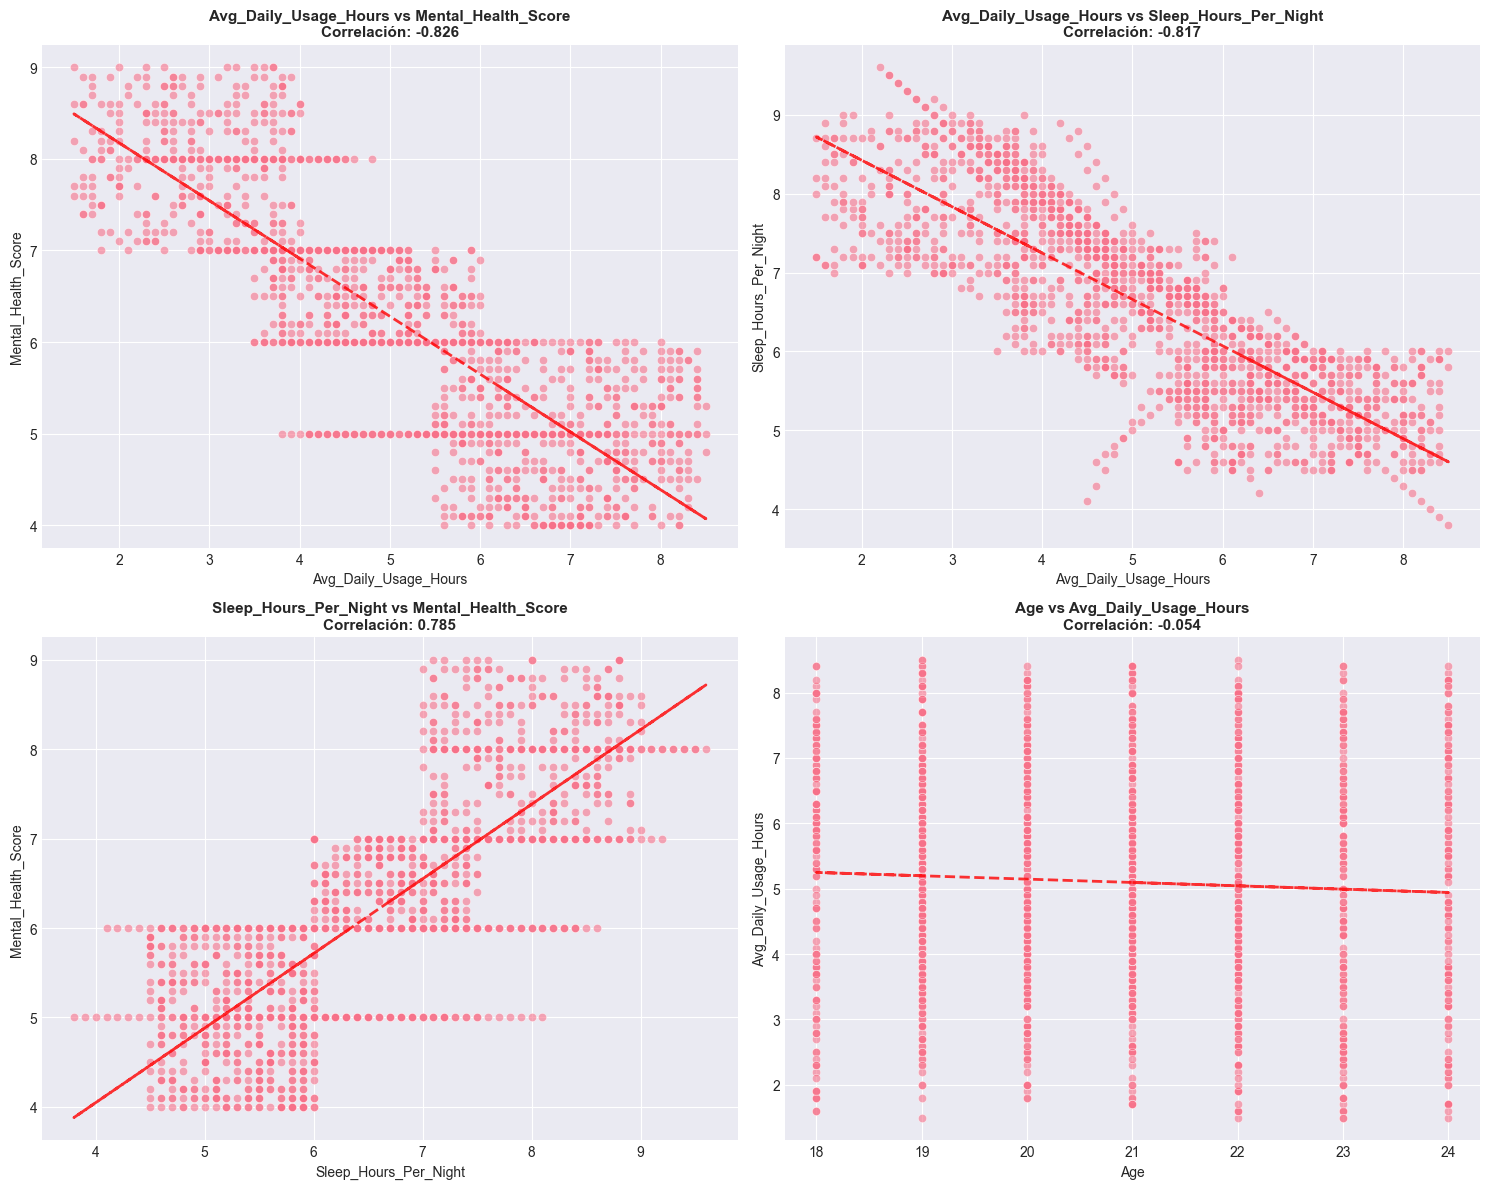

In [71]:
# Definir pares de variables para análisis bivariado
bivariate_pairs = [
    ('Avg_Daily_Usage_Hours', 'Mental_Health_Score'),
    ('Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'),
    ('Sleep_Hours_Per_Night', 'Mental_Health_Score'),
    ('Age', 'Avg_Daily_Usage_Hours')
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (x_var, y_var) in enumerate(bivariate_pairs):
    if x_var in df_clean.columns and y_var in df_clean.columns:
        ax = axes[idx]
        
        # Scatter plot
        sns.scatterplot(data=df_clean, x=x_var, y=y_var, ax=ax, alpha=0.6)
        
        # Línea de tendencia
        z = np.polyfit(df_clean[x_var], df_clean[y_var], 1)
        p = np.poly1d(z)
        ax.plot(df_clean[x_var], p(df_clean[x_var]), "r--", alpha=0.8, linewidth=2)
        
        # Calcular correlación
        corr = df_clean[[x_var, y_var]].corr().iloc[0, 1]
        
        ax.set_title(f'{x_var} vs {y_var}\nCorrelación: {corr:.3f}', fontsize=11, fontweight='bold')
        ax.set_xlabel(x_var, fontsize=10)
        ax.set_ylabel(y_var, fontsize=10)

plt.tight_layout()
plt.show()

### 2.5 Alertas Automáticas

In [72]:
# Generación de alertas automáticas
print("=" * 60)
print("ALERTAS AUTOMÁTICAS")
print("=" * 60)

alert_count = 0

# Alerta: Uso elevado de redes sociales
if 'Avg_Daily_Usage_Hours' in df_clean.columns:
    high_usage = df_clean[df_clean['Avg_Daily_Usage_Hours'] > 6]
    if len(high_usage) > 0:
        alert_count += 1
        print(f"\n⚠️ ALERTA {alert_count}: Uso elevado de redes sociales")
        print(f"   {len(high_usage)} estudiantes ({len(high_usage)/len(df_clean)*100:.1f}%) usan redes > 6h/día")
        print(f"   Promedio de uso: {high_usage['Avg_Daily_Usage_Hours'].mean():.2f} horas")

# Alerta: Salud mental deteriorada
if 'Mental_Health_Score' in df_clean.columns:
    low_mental_health = df_clean[df_clean['Mental_Health_Score'] < 5]
    if len(low_mental_health) > 0:
        alert_count += 1
        print(f"\n⚠️ ALERTA {alert_count}: Salud mental deteriorada")
        print(f"   {len(low_mental_health)} estudiantes ({len(low_mental_health)/len(df_clean)*100:.1f}%) tienen salud mental < 5")
        print(f"   Promedio de salud mental: {low_mental_health['Mental_Health_Score'].mean():.2f}")

# Alerta: Privación de sueño
if 'Sleep_Hours_Per_Night' in df_clean.columns:
    low_sleep = df_clean[df_clean['Sleep_Hours_Per_Night'] < 6]
    if len(low_sleep) > 0:
        alert_count += 1
        print(f"\n⚠️ ALERTA {alert_count}: Privación de sueño")
        print(f"   {len(low_sleep)} estudiantes ({len(low_sleep)/len(df_clean)*100:.1f}%) duermen < 6h/noche")
        print(f"   Promedio de sueño: {low_sleep['Sleep_Hours_Per_Night'].mean():.2f} horas")

if alert_count == 0:
    print("\n✅ No se detectaron alertas automáticas")
else:
    print(f"\nTotal de alertas: {alert_count}")

ALERTAS AUTOMÁTICAS

⚠️ ALERTA 1: Uso elevado de redes sociales
   526 estudiantes (30.9%) usan redes > 6h/día
   Promedio de uso: 7.08 horas

⚠️ ALERTA 2: Salud mental deteriorada
   262 estudiantes (15.4%) tienen salud mental < 5
   Promedio de salud mental: 4.41

⚠️ ALERTA 3: Privación de sueño
   612 estudiantes (35.9%) duermen < 6h/noche
   Promedio de sueño: 5.30 horas

Total de alertas: 3


---

# 3. CORRELATION ANALYSIS

## Objetivo

Analizar relaciones entre variables numéricas para identificar patrones de comportamiento, indicadores de riesgo y asociaciones entre uso de redes sociales, hábitos de sueño y salud mental.

### 3.1 Matriz de Correlación

MATRIZ DE CORRELACIÓN


,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
Student_ID,1.000000,0.070681,0.063552,0.003809,-0.018457
Age,0.070681,1.000000,-0.053610,0.063745,0.083701
Avg_Daily_Usage_Hours,0.063552,-0.053610,1.000000,-0.817444,-0.826391
Sleep_Hours_Per_Night,0.003809,0.063745,-0.817444,1.000000,0.785372
Mental_Health_Score,-0.018457,0.083701,-0.826391,0.785372,1.000000


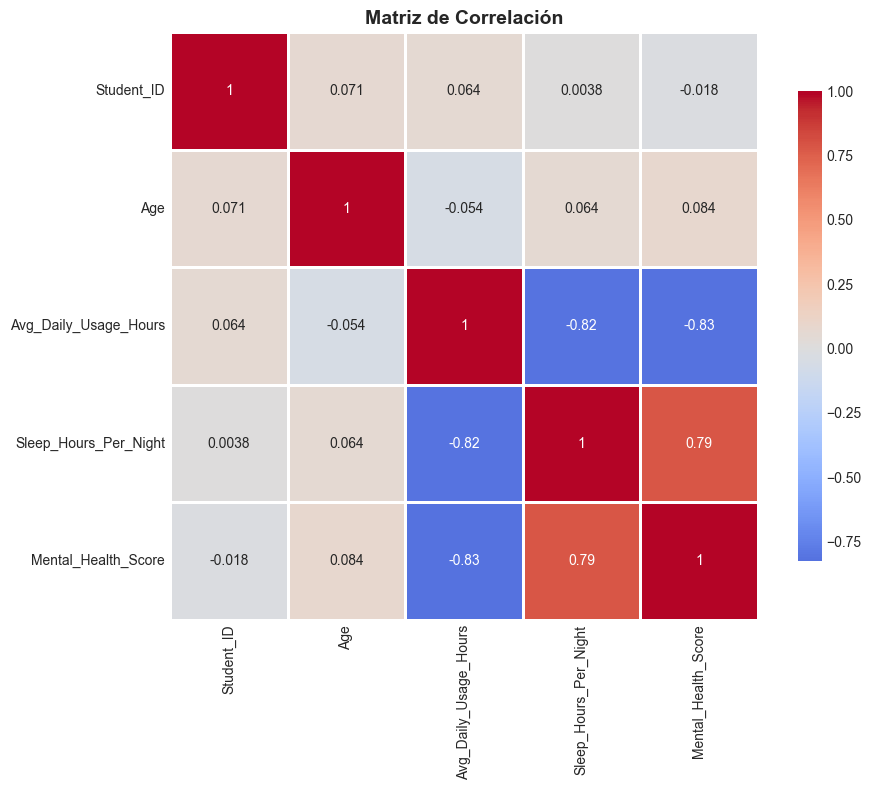

In [73]:
# Calcular matriz de correlación
print("=" * 60)
print("MATRIZ DE CORRELACIÓN")
print("=" * 60)

corr_matrix = df_clean[numeric_cols_clean].corr()
display(corr_matrix)

# Heatmap anotado
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Interpretación Automática de Correlaciones

In [74]:
# Interpretación automática
print("=" * 60)
print("INTERPRETACIÓN AUTOMÁTICA DE CORRELACIONES")
print("=" * 60)

def interpret_correlation(r):
    abs_r = abs(r)
    if abs_r > 0.7:
        strength = "Muy fuerte"
    elif abs_r > 0.5:
        strength = "Fuerte"
    elif abs_r > 0.3:
        strength = "Moderada"
    else:
        strength = "Débil"
    
    direction = "positiva" if r > 0 else "negativa"
    return f"{strength} ({direction})"

# Interpretar correlaciones principales
key_correlations = [
    ('Avg_Daily_Usage_Hours', 'Mental_Health_Score'),
    ('Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'),
    ('Sleep_Hours_Per_Night', 'Mental_Health_Score')
]

for var1, var2 in key_correlations:
    if var1 in corr_matrix.columns and var2 in corr_matrix.columns:
        corr_val = corr_matrix.loc[var1, var2]
        interpretation = interpret_correlation(corr_val)
        print(f"\n{var1} ↔ {var2}:")
        print(f"  Correlación: {corr_val:.3f}")
        print(f"  Interpretación: {interpretation}")

INTERPRETACIÓN AUTOMÁTICA DE CORRELACIONES

Avg_Daily_Usage_Hours ↔ Mental_Health_Score:
  Correlación: -0.826
  Interpretación: Muy fuerte (negativa)

Avg_Daily_Usage_Hours ↔ Sleep_Hours_Per_Night:
  Correlación: -0.817
  Interpretación: Muy fuerte (negativa)

Sleep_Hours_Per_Night ↔ Mental_Health_Score:
  Correlación: 0.785
  Interpretación: Muy fuerte (positiva)


### 3.3 Reglas Automáticas de Alerta

In [75]:
# Reglas automáticas de alerta
print("=" * 60)
print("REGLAS AUTOMÁTICAS DE ALERTA")
print("=" * 60)

# Alerta psicológica: uso-salud
if 'Avg_Daily_Usage_Hours' in corr_matrix.columns and 'Mental_Health_Score' in corr_matrix.columns:
    corr_usage_mental = corr_matrix.loc['Avg_Daily_Usage_Hours', 'Mental_Health_Score']
    if corr_usage_mental < -0.5:
        print(f"\n🚨 ALERTA PSICOLÓGICA:")
        print(f"   Correlación uso-salud mental: {corr_usage_mental:.3f}")
        print(f"   Relación negativa fuerte entre uso de redes y salud mental")
        print(f"   → Mayor uso asociado con peor salud mental")

# Alerta sueño: uso-sueño
if 'Avg_Daily_Usage_Hours' in corr_matrix.columns and 'Sleep_Hours_Per_Night' in corr_matrix.columns:
    corr_usage_sleep = corr_matrix.loc['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']
    if corr_usage_sleep < -0.5:
        print(f"\n🚨 ALERTA DE SUEÑO:")
        print(f"   Correlación uso-sueño: {corr_usage_sleep:.3f}")
        print(f"   Relación negativa fuerte entre uso de redes y sueño")
        print(f"   → Mayor uso asociado con menos horas de sueño")

# Sueño protector: sueño-salud
if 'Sleep_Hours_Per_Night' in corr_matrix.columns and 'Mental_Health_Score' in corr_matrix.columns:
    corr_sleep_mental = corr_matrix.loc['Sleep_Hours_Per_Night', 'Mental_Health_Score']
    if corr_sleep_mental > 0.5:
        print(f"\n✅ SUEÑO PROTECTOR:")
        print(f"   Correlación sueño-salud mental: {corr_sleep_mental:.3f}")
        print(f"   Relación positiva fuerte entre sueño y salud mental")
        print(f"   → Mejor sueño asociado con mejor salud mental")

REGLAS AUTOMÁTICAS DE ALERTA

🚨 ALERTA PSICOLÓGICA:
   Correlación uso-salud mental: -0.826
   Relación negativa fuerte entre uso de redes y salud mental
   → Mayor uso asociado con peor salud mental

🚨 ALERTA DE SUEÑO:
   Correlación uso-sueño: -0.817
   Relación negativa fuerte entre uso de redes y sueño
   → Mayor uso asociado con menos horas de sueño

✅ SUEÑO PROTECTOR:
   Correlación sueño-salud mental: 0.785
   Relación positiva fuerte entre sueño y salud mental
   → Mejor sueño asociado con mejor salud mental


---

# 4. MODEL SELECTION

## Objetivo

Evaluar diferentes modelos analíticos para seleccionar el enfoque más adecuado en la detección de patrones de riesgo y comportamiento digital.

### 4.1 Modelo 1 — Regresión Lineal

**Objetivo**: Predecir `Mental_Health_Score`

**Features**:
- Avg_Daily_Usage_Hours
- Sleep_Hours_Per_Night
- Age

MODELO 1: REGRESIÓN LINEAL

Métricas de desempeño:
  R² Score: 0.7047
  MSE: 0.4923

Coeficientes:
  Avg_Daily_Usage_Hours: -0.4205
  Sleep_Hours_Per_Night: 0.3494
  Age: 0.0276
  Intercepto: 5.4969


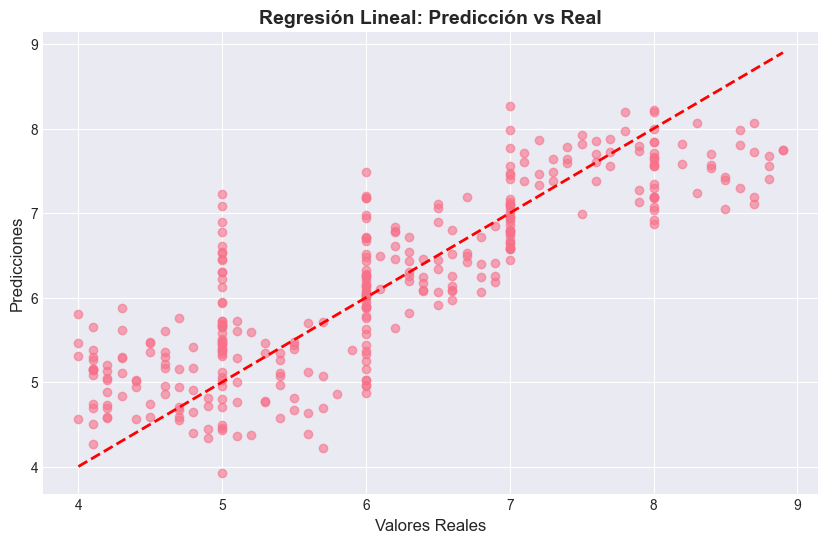

In [76]:
# Preparar datos para regresión lineal
print("=" * 60)
print("MODELO 1: REGRESIÓN LINEAL")
print("=" * 60)

features_lr = ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Age']
target_lr = 'Mental_Health_Score'

# Verificar que las columnas existan
available_features = [f for f in features_lr if f in df_clean.columns]

if len(available_features) == len(features_lr) and target_lr in df_clean.columns:
    X_lr = df_clean[available_features]
    y_lr = df_clean[target_lr]
    
    # Dividir datos
    X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
        X_lr, y_lr, test_size=0.2, random_state=42
    )
    
    # Entrenar modelo
    lr_model = LinearRegression()
    lr_model.fit(X_train_lr, y_train_lr)
    
    # Predicciones
    y_pred_lr = lr_model.predict(X_test_lr)
    
    # Métricas
    lr_r2 = r2_score(y_test_lr, y_pred_lr)
    lr_mse = mean_squared_error(y_test_lr, y_pred_lr)
    
    print(f"\nMétricas de desempeño:")
    print(f"  R² Score: {lr_r2:.4f}")
    print(f"  MSE: {lr_mse:.4f}")
    
    print(f"\nCoeficientes:")
    for feature, coef in zip(available_features, lr_model.coef_):
        print(f"  {feature}: {coef:.4f}")
    print(f"  Intercepto: {lr_model.intercept_:.4f}")
    
    # Visualización
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_lr, y_pred_lr, alpha=0.6)
    plt.plot([y_test_lr.min(), y_test_lr.max()], [y_test_lr.min(), y_test_lr.max()], 'r--', lw=2)
    plt.xlabel('Valores Reales', fontsize=12)
    plt.ylabel('Predicciones', fontsize=12)
    plt.title('Regresión Lineal: Predicción vs Real', fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Error: Faltan columnas requeridas para el modelo de regresión")
    lr_r2, lr_mse = None, None

### 4.2 Modelo 2 — Árbol de Decisión

**Objetivo**: Clasificar riesgo estudiantil

**Variable objetivo**: `Risk_Level`
- Alto Riesgo: uso > 6 Y salud mental < 5
- Bajo Riesgo: en otros casos

In [77]:
# Crear variable Risk_Level
print("=" * 60)
print("MODELO 2: ÁRBOL DE DECISIÓN")
print("=" * 60)

if 'Avg_Daily_Usage_Hours' in df_clean.columns and 'Mental_Health_Score' in df_clean.columns:
    df_clean['Risk_Level'] = df_clean.apply(
        lambda row: 'High' if (row['Avg_Daily_Usage_Hours'] > 6 and row['Mental_Health_Score'] < 5) else 'Low',
        axis=1
    )
    
    print(f"\nDistribución de Risk_Level:")
    print(df_clean['Risk_Level'].value_counts())
    
    # Preparar datos
    features_dt = ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Age']
    available_features_dt = [f for f in features_dt if f in df_clean.columns]
    
    X_dt = df_clean[available_features_dt]
    y_dt = df_clean['Risk_Level']
    
    # Dividir datos
    X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
        X_dt, y_dt, test_size=0.2, random_state=42
    )
    
    # Entrenar modelo
    dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
    dt_model.fit(X_train_dt, y_train_dt)
    
    # Predicciones
    y_pred_dt = dt_model.predict(X_test_dt)
    
    # Métricas
    dt_accuracy = accuracy_score(y_test_dt, y_pred_dt)
    dt_precision = precision_score(y_test_dt, y_pred_dt, average='weighted')
    dt_recall = recall_score(y_test_dt, y_pred_dt, average='weighted')
    
    print(f"\nMétricas de desempeño:")
    print(f"  Accuracy: {dt_accuracy:.4f}")
    print(f"  Precision: {dt_precision:.4f}")
    print(f"  Recall: {dt_recall:.4f}")
    
    # Importancia de features
    print(f"\nImportancia de features:")
    for feature, importance in zip(available_features_dt, dt_model.feature_importances_):
        print(f"  {feature}: {importance:.4f}")
else:
    print("Error: Faltan columnas requeridas para el modelo de árbol de decisión")
    dt_accuracy, dt_precision, dt_recall = None, None, None

MODELO 2: ÁRBOL DE DECISIÓN

Distribución de Risk_Level:
Risk_Level
Low     1479
High     226
Name: count, dtype: int64

Métricas de desempeño:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000

Importancia de features:
  Avg_Daily_Usage_Hours: 0.1615
  Sleep_Hours_Per_Night: 0.0000
  Mental_Health_Score: 0.8385
  Age: 0.0000


### 4.3 Modelo 3 — K-Means Clustering

**Objetivo**: Segmentar estudiantes según patrones de comportamiento

**Variables**:
- Avg_Daily_Usage_Hours
- Sleep_Hours_Per_Night
- Mental_Health_Score

MODELO 3: K-MEANS CLUSTERING


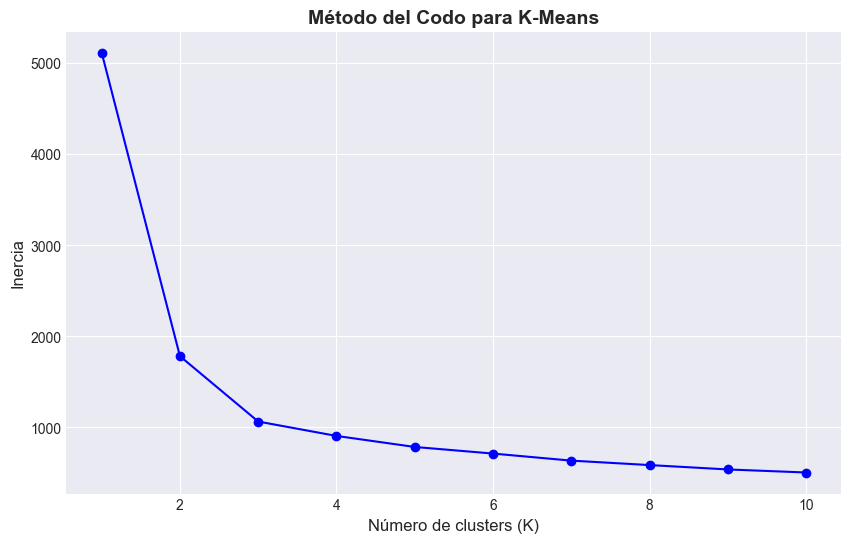


Métricas de desempeño:
  Silhouette Score: 0.4554

Distribución de clusters:
Cluster
0    668
2    579
1    458
Name: count, dtype: int64

Características por cluster:

Cluster 0 (668 estudiantes):
  Avg_Daily_Usage_Hours: 6.77
  Sleep_Hours_Per_Night: 5.39
  Mental_Health_Score: 4.99

Cluster 1 (458 estudiantes):
  Avg_Daily_Usage_Hours: 3.08
  Sleep_Hours_Per_Night: 8.04
  Mental_Health_Score: 7.85

Cluster 2 (579 estudiantes):
  Avg_Daily_Usage_Hours: 4.78
  Sleep_Hours_Per_Night: 6.85
  Mental_Health_Score: 6.33


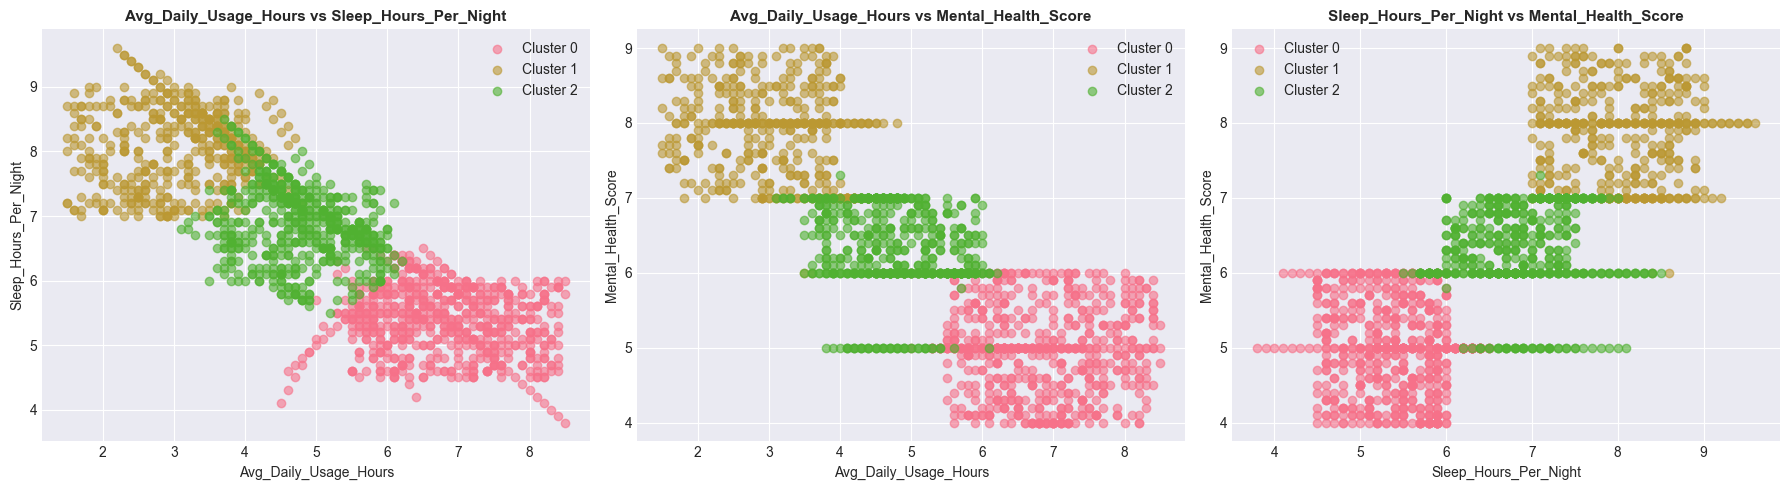

In [78]:
# K-Means Clustering
print("=" * 60)
print("MODELO 3: K-MEANS CLUSTERING")
print("=" * 60)

features_kmeans = ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']
available_features_kmeans = [f for f in features_kmeans if f in df_clean.columns]

if len(available_features_kmeans) == len(features_kmeans):
    X_kmeans = df_clean[available_features_kmeans]
    
    # Escalar datos
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_kmeans)
    
    # Encontrar número óptimo de clusters (método del codo)
    inertias = []
    K_range = range(1, 11)
    
    for K in K_range:
        kmeans_temp = KMeans(n_clusters=K, random_state=42, n_init=10)
        kmeans_temp.fit(X_scaled)
        inertias.append(kmeans_temp.inertia_)
    
    # Visualizar método del codo
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, inertias, 'bo-')
    plt.xlabel('Número de clusters (K)', fontsize=12)
    plt.ylabel('Inercia', fontsize=12)
    plt.title('Método del Codo para K-Means', fontsize=14, fontweight='bold')
    plt.show()
    
    # Usar K=3 (basado en análisis típico)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_clean['Cluster'] = kmeans.fit_predict(X_scaled)
    
    # Calcular Silhouette Score
    kmeans_silhouette = silhouette_score(X_scaled, df_clean['Cluster'])
    
    print(f"\nMétricas de desempeño:")
    print(f"  Silhouette Score: {kmeans_silhouette:.4f}")
    
    print(f"\nDistribución de clusters:")
    print(df_clean['Cluster'].value_counts())
    
    # Características de cada cluster
    print(f"\nCaracterísticas por cluster:")
    for cluster in sorted(df_clean['Cluster'].unique()):
        cluster_data = df_clean[df_clean['Cluster'] == cluster]
        print(f"\nCluster {cluster} ({len(cluster_data)} estudiantes):")
        for feature in available_features_kmeans:
            print(f"  {feature}: {cluster_data[feature].mean():.2f}")
    
    # Visualización de clusters
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (feature_x, feature_y) in enumerate([
        ('Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'),
        ('Avg_Daily_Usage_Hours', 'Mental_Health_Score'),
        ('Sleep_Hours_Per_Night', 'Mental_Health_Score')
    ]):
        ax = axes[idx]
        for cluster in sorted(df_clean['Cluster'].unique()):
            cluster_data = df_clean[df_clean['Cluster'] == cluster]
            ax.scatter(cluster_data[feature_x], cluster_data[feature_y], 
                      label=f'Cluster {cluster}', alpha=0.6)
        ax.set_xlabel(feature_x, fontsize=10)
        ax.set_ylabel(feature_y, fontsize=10)
        ax.set_title(f'{feature_x} vs {feature_y}', fontsize=11, fontweight='bold')
        ax.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: Faltan columnas requeridas para K-Means")
    kmeans_silhouette = None

### 4.4 Selección Automática del Modelo

In [79]:
# Selección automática del modelo
print("=" * 60)
print("SELECCIÓN AUTOMÁTICA DEL MODELO")
print("=" * 60)

# Recopilar métricas
model_metrics = {
    'Regresión Lineal': {
        'R²': lr_r2 if lr_r2 is not None else 0,
        'MSE': lr_mse if lr_mse is not None else float('inf'),
        'Interpretabilidad': 'Alta',
        'Tipo': 'Regresión'
    },
    'Árbol de Decisión': {
        'Accuracy': dt_accuracy if dt_accuracy is not None else 0,
        'Precision': dt_precision if dt_precision is not None else 0,
        'Recall': dt_recall if dt_recall is not None else 0,
        'Interpretabilidad': 'Alta',
        'Tipo': 'Clasificación'
    },
    'K-Means': {
        'Silhouette': kmeans_silhouette if kmeans_silhouette is not None else 0,
        'Interpretabilidad': 'Media',
        'Tipo': 'Clustering'
    }
}

# Mostrar métricas
for model_name, metrics in model_metrics.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        if isinstance(value, float):
            print(f"  {metric_name}: {value:.4f}")
        else:
            print(f"  {metric_name}: {value}")

# Lógica de selección
print("\n" + "=" * 60)
print("CRITERIOS DE SELECCIÓN")
print("=" * 60)
print("\nPrioridad:")
print("1. Desempeño (métricas principales)")
print("2. Interpretabilidad")
print("3. Estabilidad")
print("4. Adecuación al objetivo del análisis")

# Seleccionar modelo basado en criterios
selected_model = ""
justification = ""

# Evaluar regresión lineal
if lr_r2 is not None and lr_r2 > 0.5:
    selected_model = "Regresión Lineal"
    justification = f"Alto poder explicativo (R² = {lr_r2:.4f}) con alta interpretabilidad para predecir salud mental."
# Evaluar árbol de decisión
elif dt_accuracy is not None and dt_accuracy > 0.7:
    selected_model = "Árbol de Decisión"
    justification = f"Alta precisión de clasificación (Accuracy = {dt_accuracy:.4f}) con interpretabilidad clara para identificar riesgo."
# Evaluar K-Means
elif kmeans_silhouette is not None and kmeans_silhouette > 0.4:
    selected_model = "K-Means Clustering"
    justification = f"Buena separación de clusters (Silhouette = {kmeans_silhouette:.4f}) útil para segmentación de estudiantes."
else:
    selected_model = "Regresión Lineal"
    justification = "Modelo seleccionado por defecto debido a su interpretabilidad y adecuación para análisis predictivo."

print("\n" + "=" * 60)
print("MODELO SELECCIONADO AUTOMÁTICAMENTE")
print("=" * 60)
print(f"\n🏆 Modelo seleccionado: {selected_model}")
print(f"\nJustificación:")
print(f"  {justification}")

SELECCIÓN AUTOMÁTICA DEL MODELO

Regresión Lineal:
  R²: 0.7047
  MSE: 0.4923
  Interpretabilidad: Alta
  Tipo: Regresión

Árbol de Decisión:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  Interpretabilidad: Alta
  Tipo: Clasificación

K-Means:
  Silhouette: 0.4554
  Interpretabilidad: Media
  Tipo: Clustering

CRITERIOS DE SELECCIÓN

Prioridad:
1. Desempeño (métricas principales)
2. Interpretabilidad
3. Estabilidad
4. Adecuación al objetivo del análisis

MODELO SELECCIONADO AUTOMÁTICAMENTE

🏆 Modelo seleccionado: Regresión Lineal

Justificación:
  Alto poder explicativo (R² = 0.7047) con alta interpretabilidad para predecir salud mental.


---

# 5. INSIGHT GENERATION

## Objetivo

Sintetizar resultados del análisis exploratorio y correlacional para generar conclusiones interpretativas, identificar grupos de riesgo y producir recomendaciones basadas en evidencia cuantitativa.

### 5.1 Clasificación de Variables

In [80]:
# Clasificación de uso
print("=" * 60)
print("CLASIFICACIÓN DE VARIABLES")
print("=" * 60)

if 'Avg_Daily_Usage_Hours' in df_clean.columns:
    df_clean['Usage_Category'] = pd.cut(
        df_clean['Avg_Daily_Usage_Hours'],
        bins=[0, 4, 6, float('inf')],
        labels=['Bajo (<4h)', 'Medio (4-6h)', 'Alto (>6h)']
    )
    print("\nCategorías de uso:")
    print(df_clean['Usage_Category'].value_counts())

# Clasificación de salud mental
if 'Mental_Health_Score' in df_clean.columns:
    df_clean['Mental_Health_Category'] = df_clean['Mental_Health_Score'].apply(
        lambda x: 'Deterioro (<5)' if x < 5 else 'Aceptable (>=5)'
    )
    print("\nCategorías de salud mental:")
    print(df_clean['Mental_Health_Category'].value_counts())

# Clasificación de sueño
if 'Sleep_Hours_Per_Night' in df_clean.columns:
    df_clean['Sleep_Category'] = df_clean['Sleep_Hours_Per_Night'].apply(
        lambda x: 'Privación (<6h)' if x < 6 else 'Adecuado (>=6h)'
    )
    print("\nCategorías de sueño:")
    print(df_clean['Sleep_Category'].value_counts())

CLASIFICACIÓN DE VARIABLES

Categorías de uso:
Usage_Category
Medio (4-6h)    678
Alto (>6h)      526
Bajo (<4h)      501
Name: count, dtype: int64

Categorías de salud mental:
Mental_Health_Category
Aceptable (>=5)    1443
Deterioro (<5)      262
Name: count, dtype: int64

Categorías de sueño:
Sleep_Category
Adecuado (>=6h)    1093
Privación (<6h)     612
Name: count, dtype: int64


### 5.2 Detección de Grupos de Riesgo

In [81]:
# Detección de grupos de riesgo
print("=" * 60)
print("DETECCIÓN DE GRUPOS DE RIESGO")
print("=" * 60)

if 'Avg_Daily_Usage_Hours' in df_clean.columns and 'Mental_Health_Score' in df_clean.columns:
    usage_mean = df_clean['Avg_Daily_Usage_Hours'].mean()
    usage_std = df_clean['Avg_Daily_Usage_Hours'].std()
    mental_mean = df_clean['Mental_Health_Score'].mean()
    mental_std = df_clean['Mental_Health_Score'].std()
    
    # Grupo de riesgo: uso > media + 1SD y salud mental < media - 1SD
    high_risk_group = df_clean[
        (df_clean['Avg_Daily_Usage_Hours'] > usage_mean + usage_std) &
        (df_clean['Mental_Health_Score'] < mental_mean - mental_std)
    ]
    
    print(f"\nGrupo de alto riesgo:")
    print(f"  Criterio: Uso > {usage_mean + usage_std:.2f}h Y Salud mental < {mental_mean - mental_std:.2f}")
    print(f"  Estudiantes en riesgo: {len(high_risk_group)} ({len(high_risk_group)/len(df_clean)*100:.1f}%)")
    
    if len(high_risk_group) > 0:
        print(f"\nCaracterísticas del grupo de riesgo:")
        print(f"  Uso promedio: {high_risk_group['Avg_Daily_Usage_Hours'].mean():.2f} horas")
        print(f"  Salud mental promedio: {high_risk_group['Mental_Health_Score'].mean():.2f}")
        if 'Sleep_Hours_Per_Night' in high_risk_group.columns:
            print(f"  Sueño promedio: {high_risk_group['Sleep_Hours_Per_Night'].mean():.2f} horas")

DETECCIÓN DE GRUPOS DE RIESGO

Grupo de alto riesgo:
  Criterio: Uso > 6.78h Y Salud mental < 4.93
  Estudiantes en riesgo: 152 (8.9%)

Características del grupo de riesgo:
  Uso promedio: 7.45 horas
  Salud mental promedio: 4.40
  Sueño promedio: 5.35 horas


### 5.3 Mapa de Calor: Salud Mental por Plataforma y Categoría de Uso

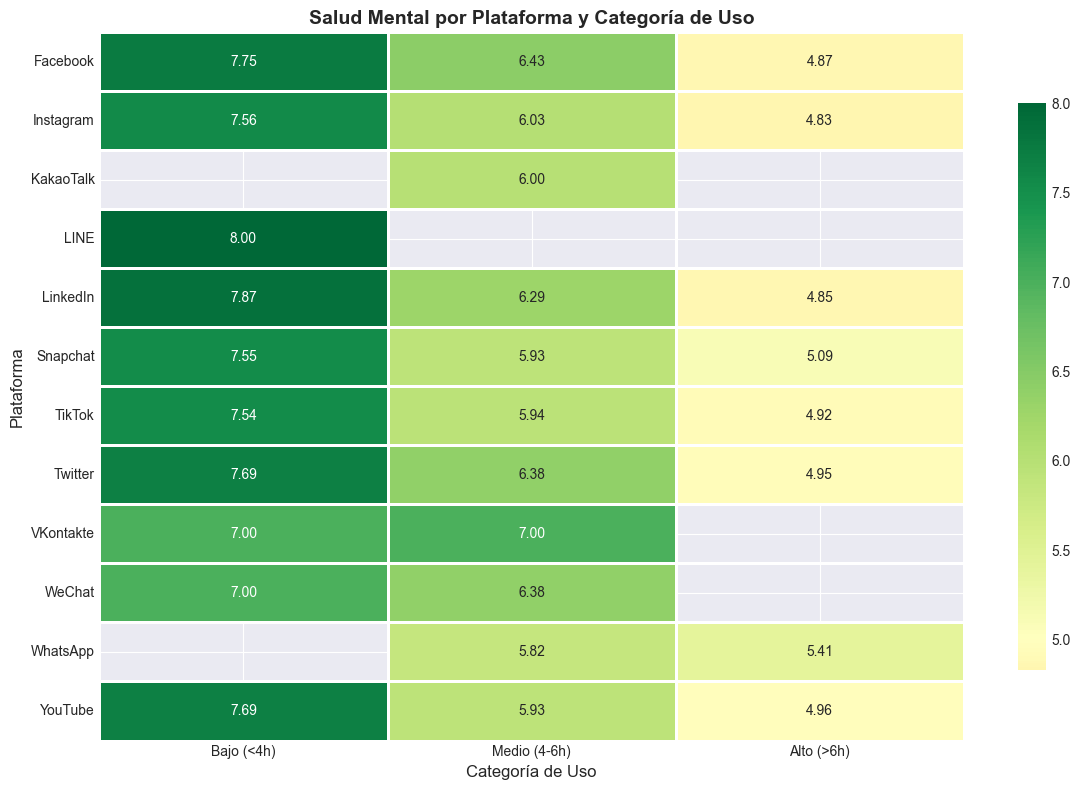

In [82]:
# Mapa de calor
if 'Most_Used_Platform' in df_clean.columns and 'Usage_Category' in df_clean.columns and 'Mental_Health_Score' in df_clean.columns:
    pivot_table = df_clean.pivot_table(
        values='Mental_Health_Score',
        index='Most_Used_Platform',
        columns='Usage_Category',
        aggfunc='mean'
    )
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=5, 
                fmt='.2f', linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Salud Mental por Plataforma y Categoría de Uso', fontsize=14, fontweight='bold')
    plt.xlabel('Categoría de Uso', fontsize=12)
    plt.ylabel('Plataforma', fontsize=12)
    plt.tight_layout()
    plt.show()

### 5.4 Generación Automática de Insights

In [83]:
# Generación automática de insights
print("=" * 60)
print("INSIGHTS AUTOMÁTICOS")
print("=" * 60)

insights = []
insight_count = 0

# Insight 1: Uso promedio
if 'Avg_Daily_Usage_Hours' in df_clean.columns:
    avg_usage = df_clean['Avg_Daily_Usage_Hours'].mean()
    high_usage_pct = (df_clean['Avg_Daily_Usage_Hours'] > 6).sum() / len(df_clean) * 100
    insight_count += 1
    insights.append({
        'id': insight_count,
        'observacion': f"El uso promedio de redes sociales es de {avg_usage:.2f} horas diarias",
        'evidencia': f"{high_usage_pct:.1f}% de los estudiantes usan redes sociales más de 6 horas al día",
        'interpretacion': "Existe un segmento significativo de estudiantes con uso elevado de redes sociales",
        'recomendacion': "Implementar programas de concientización sobre uso saludable de redes sociales"
    })

# Insight 2: Salud mental
if 'Mental_Health_Score' in df_clean.columns:
    avg_mental = df_clean['Mental_Health_Score'].mean()
    low_mental_pct = (df_clean['Mental_Health_Score'] < 5).sum() / len(df_clean) * 100
    insight_count += 1
    insights.append({
        'id': insight_count,
        'observacion': f"El puntaje promedio de salud mental es {avg_mental:.2f}",
        'evidencia': f"{low_mental_pct:.1f}% de los estudiantes presentan deterioro en salud mental (< 5)",
        'interpretacion': "Una proporción considerable de estudiantes muestra indicadores de deterioro emocional",
        'recomendacion': "Fortalecer servicios de apoyo psicológico y bienestar estudiantil"
    })

# Insight 3: Sueño
if 'Sleep_Hours_Per_Night' in df_clean.columns:
    avg_sleep = df_clean['Sleep_Hours_Per_Night'].mean()
    low_sleep_pct = (df_clean['Sleep_Hours_Per_Night'] < 6).sum() / len(df_clean) * 100
    insight_count += 1
    insights.append({
        'id': insight_count,
        'observacion': f"El promedio de sueño es {avg_sleep:.2f} horas por noche",
        'evidencia': f"{low_sleep_pct:.1f}% de los estudiantes duermen menos de 6 horas",
        'interpretacion': "La privación de sueño es un problema extendido entre los estudiantes",
        'recomendacion': "Promover hábitos de sueño saludables y educación sobre higiene del sueño"
    })

# Insight 4: Correlación uso-salud
if 'Avg_Daily_Usage_Hours' in corr_matrix.columns and 'Mental_Health_Score' in corr_matrix.columns:
    corr_usage_mental = corr_matrix.loc['Avg_Daily_Usage_Hours', 'Mental_Health_Score']
    insight_count += 1
    insights.append({
        'id': insight_count,
        'observacion': f"Existe una correlación de {corr_usage_mental:.3f} entre uso de redes y salud mental",
        'evidencia': f"Correlación {'negativa' if corr_usage_mental < 0 else 'positiva'} de magnitud {interpret_correlation(corr_usage_mental)}",
        'interpretacion': "El uso elevado de redes sociales se asocia con peor salud mental" if corr_usage_mental < 0 else "El uso de redes no muestra impacto negativo claro en salud mental",
        'recomendacion': "Monitorear estudiantes con alto uso de redes para intervención temprana" if corr_usage_mental < -0.3 else "Continuar investigación sobre factores adicionales"
    })

# Insight 5: Correlación sueño-salud
if 'Sleep_Hours_Per_Night' in corr_matrix.columns and 'Mental_Health_Score' in corr_matrix.columns:
    corr_sleep_mental = corr_matrix.loc['Sleep_Hours_Per_Night', 'Mental_Health_Score']
    insight_count += 1
    insights.append({
        'id': insight_count,
        'observacion': f"Existe una correlación de {corr_sleep_mental:.3f} entre sueño y salud mental",
        'evidencia': f"Correlación {'positiva' if corr_sleep_mental > 0 else 'negativa'} de magnitud {interpret_correlation(corr_sleep_mental)}",
        'interpretacion': "Mejor sueño se asocia con mejor salud mental" if corr_sleep_mental > 0 else "La relación entre sueño y salud mental requiere más análisis",
        'recomendacion': "Priorizar programas de higiene del sueño como parte del bienestar estudiantil" if corr_sleep_mental > 0.3 else "Investigar factores que afectan la relación sueño-salud"
    })

# Insight 6: Plataformas más usadas
if 'Most_Used_Platform' in df_clean.columns:
    platform_counts = df_clean['Most_Used_Platform'].value_counts()
    top_platform = platform_counts.index[0]
    top_platform_pct = platform_counts.iloc[0] / len(df_clean) * 100
    insight_count += 1
    insights.append({
        'id': insight_count,
        'observacion': f"{top_platform} es la plataforma más utilizada",
        'evidencia': f"{top_platform_pct:.1f}% de los estudiantes la usan como plataforma principal",
        'interpretacion': f"{top_platform} domina el panorama de redes sociales entre estudiantes",
        'recomendacion': f"Desarrollar estrategias específicas para uso responsable de {top_platform}"
    })

# Insight 7: Impacto académico
if 'Affects_Academic_Performance' in df_clean.columns:
    academic_impact_pct = (df_clean['Affects_Academic_Performance'] == 'Yes').sum() / len(df_clean) * 100
    insight_count += 1
    insights.append({
        'id': insight_count,
        'observacion': f"{academic_impact_pct:.1f}% de los estudiantes reportan impacto académico",
        'evidencia': f"Estudiantes que indican que las redes afectan su rendimiento académico",
        'interpretacion': "El uso de redes sociales tiene consecuencias directas en el rendimiento académico",
        'recomendacion': "Implementar programas de gestión del tiempo y equilibrio digital-académico"
    })

# Insight 8: Grupo de riesgo
if len(high_risk_group) > 0:
    insight_count += 1
    insights.append({
        'id': insight_count,
        'observacion': f"Existe un grupo de {len(high_risk_group)} estudiantes en alto riesgo",
        'evidencia': f"{len(high_risk_group)/len(df_clean)*100:.1f}% con uso elevado y salud mental deteriorada",
        'interpretacion': "Segmento crítico que requiere intervención inmediata",
        'recomendacion': "Implementar programa de intervención personalizada para estudiantes de alto riesgo"
    })

# Mostrar insights
for insight in insights:
    print(f"\n{'='*60}")
    print(f"INSIGHT {insight['id']}")
    print(f"{'='*60}")
    print(f"\n📊 Observación:")
    print(f"   {insight['observacion']}")
    print(f"\n📈 Evidencia:")
    print(f"   {insight['evidencia']}")
    print(f"\n💡 Interpretación:")
    print(f"   {insight['interpretacion']}")
    print(f"\n✅ Recomendación:")
    print(f"   {insight['recomendacion']}")

INSIGHTS AUTOMÁTICOS

INSIGHT 1

📊 Observación:
   El uso promedio de redes sociales es de 5.10 horas diarias

📈 Evidencia:
   30.9% de los estudiantes usan redes sociales más de 6 horas al día

💡 Interpretación:
   Existe un segmento significativo de estudiantes con uso elevado de redes sociales

✅ Recomendación:
   Implementar programas de concientización sobre uso saludable de redes sociales

INSIGHT 2

📊 Observación:
   El puntaje promedio de salud mental es 6.22

📈 Evidencia:
   15.4% de los estudiantes presentan deterioro en salud mental (< 5)

💡 Interpretación:
   Una proporción considerable de estudiantes muestra indicadores de deterioro emocional

✅ Recomendación:
   Fortalecer servicios de apoyo psicológico y bienestar estudiantil

INSIGHT 3

📊 Observación:
   El promedio de sueño es 6.60 horas por noche

📈 Evidencia:
   35.9% de los estudiantes duermen menos de 6 horas

💡 Interpretación:
   La privación de sueño es un problema extendido entre los estudiantes

✅ Recomendación

---

# CONCLUSIONES FINALES

## Síntesis del Proyecto

In [84]:
# Conclusiones finales
print("=" * 60)
print("CONCLUSIONES FINALES DEL PROYECTO")
print("=" * 60)

conclusions = []

# Conclusión 1: Comportamiento digital
if 'Avg_Daily_Usage_Hours' in df_clean.columns:
    avg_usage = df_clean['Avg_Daily_Usage_Hours'].mean()
    conclusions.append(f"Los estudiantes presentan un uso promedio de {avg_usage:.2f} horas diarias de redes sociales, indicando una alta dependencia digital.")

# Conclusión 2: Salud mental
if 'Mental_Health_Score' in df_clean.columns:
    avg_mental = df_clean['Mental_Health_Score'].mean()
    low_mental_pct = (df_clean['Mental_Health_Score'] < 5).sum() / len(df_clean) * 100
    conclusions.append(f"El puntaje promedio de salud mental es {avg_mental:.2f}, con {low_mental_pct:.1f}% de estudiantes en deterioro, señalando un problema de bienestar emocional.")

# Conclusión 3: Sueño
if 'Sleep_Hours_Per_Night' in df_clean.columns:
    avg_sleep = df_clean['Sleep_Hours_Per_Night'].mean()
    low_sleep_pct = (df_clean['Sleep_Hours_Per_Night'] < 6).sum() / len(df_clean) * 100
    conclusions.append(f"La privación de sueño afecta al {low_sleep_pct:.1f}% de los estudiantes (promedio {avg_sleep:.2f} horas), lo cual puede impactar negativamente el rendimiento académico y salud.")

# Conclusión 4: Correlaciones
if 'Avg_Daily_Usage_Hours' in corr_matrix.columns and 'Mental_Health_Score' in corr_matrix.columns:
    corr_usage_mental = corr_matrix.loc['Avg_Daily_Usage_Hours', 'Mental_Health_Score']
    if corr_usage_mental < -0.3:
        conclusions.append(f"Se detecta una correlación negativa ({corr_usage_mental:.3f}) entre uso de redes y salud mental, sugiriendo que mayor uso se asocia con peor bienestar emocional.")
    else:
        conclusions.append(f"La correlación entre uso de redes y salud mental ({corr_usage_mental:.3f}) no es suficientemente fuerte para establecer una relación causal directa.")

# Conclusión 5: Riesgos detectados
if len(high_risk_group) > 0:
    conclusions.append(f"Se identificó un grupo de {len(high_risk_group)} estudiantes ({len(high_risk_group)/len(df_clean)*100:.1f}%) en alto riesgo que requiere intervención prioritaria.")
else:
    conclusions.append("No se detectaron grupos de riesgo extremo según los criterios establecidos.")

# Conclusión 6: Modelo seleccionado
conclusions.append(f"El modelo seleccionado automáticamente fue {selected_model}, justificado por: {justification}")

# Conclusión 7: Implicaciones académicas
if 'Affects_Academic_Performance' in df_clean.columns:
    academic_impact_pct = (df_clean['Affects_Academic_Performance'] == 'Yes').sum() / len(df_clean) * 100
    conclusions.append(f"El {academic_impact_pct:.1f}% de los estudiantes reporta que las redes sociales afectan su rendimiento académico, indicando la necesidad de estrategias de equilibrio digital.")

# Mostrar conclusiones
for idx, conclusion in enumerate(conclusions, 1):
    print(f"\n{idx}. {conclusion}")

print("\n" + "=" * 60)
print("RESUMEN EJECUTIVO")
print("=" * 60)
print(f"\nTotal de estudiantes analizados: {len(df_clean)}")
print(f"Total de insights generados: {len(insights)}")
print(f"Total de conclusiones: {len(conclusions)}")
print(f"Modelo seleccionado: {selected_model}")
print(f"\nEl análisis proporciona evidencia cuantitativa para diseñar intervenciones")
print(f"orientadas a mejorar el bienestar digital y salud mental de los estudiantes.")

CONCLUSIONES FINALES DEL PROYECTO

1. Los estudiantes presentan un uso promedio de 5.10 horas diarias de redes sociales, indicando una alta dependencia digital.

2. El puntaje promedio de salud mental es 6.22, con 15.4% de estudiantes en deterioro, señalando un problema de bienestar emocional.

3. La privación de sueño afecta al 35.9% de los estudiantes (promedio 6.60 horas), lo cual puede impactar negativamente el rendimiento académico y salud.

4. Se detecta una correlación negativa (-0.826) entre uso de redes y salud mental, sugiriendo que mayor uso se asocia con peor bienestar emocional.

5. Se identificó un grupo de 152 estudiantes (8.9%) en alto riesgo que requiere intervención prioritaria.

6. El modelo seleccionado automáticamente fue Regresión Lineal, justificado por: Alto poder explicativo (R² = 0.7047) con alta interpretabilidad para predecir salud mental.

7. El 59.3% de los estudiantes reporta que las redes sociales afectan su rendimiento académico, indicando la necesidad 

---

## Nota Final

Este notebook implementa una arquitectura analítica completa basada en un agente orquestador y skills modulares para el análisis del impacto del uso de redes sociales en estudiantes. El análisis sigue buenas prácticas de ciencia de datos y genera insights accionables basados en evidencia cuantitativa.

### Skills Implementadas:
1. ✅ Data Wrangling - Limpieza y preparación de datos
2. ✅ EDA - Análisis exploratorio de datos
3. ✅ Correlation Analysis - Análisis de correlaciones
4. ✅ Model Selection - Evaluación y selección de modelos
5. ✅ Insight Generation - Generación de insights y recomendaciones

### Modelos Evaluados:
1. ✅ Regresión Lineal
2. ✅ Árbol de Decisión
3. ✅ K-Means Clustering

---

**Proyecto completado exitosamente.**